# Machine failure prediction for steel manufacturing

**Project type:** Binary classification  
**Contribution:** Individual  
**Runtime:** Google Colab, CPU  
**Target:** `Machine failure` (1 = failure, 0 = no failure)

## Project summary

This project studies whether operational measurements can identify machines at elevated risk of failure. The supplied data are **synthetic**. They resemble an industrial predictive-maintenance problem, but results from this notebook must not be presented as measured performance at a TATA Steel plant. The labeled training file contains 136,429 rows and 2,148 failures (1.57%). The separate 90,954-row test file has no `Machine failure` labels. It can receive predictions, but cannot provide a performance score.

The notebook follows the supplied submission template: understand the data and business question, inspect distributions and relationships, test a few descriptive hypotheses, prepare features, compare models, evaluate a locked holdout, explain the selected model, and save an artifact for the Streamlit application. It compares a class-weighted logistic regression, random forest, XGBoost, and LightGBM. Their thresholds are chosen on a validation set using F2, which puts more weight on catching failures than on precision. Average precision and false-alert counts are reported alongside F2 so the alert workload remains visible.

The five failure-type flags (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) are useful for descriptive analysis, but they indicate events that have already happened and are excluded from modeling and app inputs. The `id` and `Product ID` fields are identifiers, not operational measurements, so they are excluded too. The notebook creates physically interpretable derived measurements from temperature, speed, torque, and wear. Splits are stratified, and imputation, encoding, and scaling are fitted inside training pipelines.

The final model is selected on validation data, evaluated once on a labeled holdout, then applied to the supplied unlabeled test file. The resulting predictions are research outputs. Before operational use, a plant would need timestamped machine histories, a defined prediction horizon, measurement availability checks, calibration, drift monitoring, and prospective validation against real maintenance outcomes.

**Sources:** [scikit-learn model selection](https://scikit-learn.org/stable/model_selection.html), [XGBoost Python API](https://xgboost.readthedocs.io/en/stable/python/python_api.html), [LightGBM Python API](https://lightgbm.readthedocs.io/en/latest/Python-API.html).


## Problem statement and stakeholder value

Predict the probability of `Machine failure` from measurements that could be observed before a failure. Maintenance planners could use a validated alert threshold to prioritize inspection. The model does not determine a root cause or prescribe repair. The supplied rows have no timestamp or machine history, so this is **row-level classification**, not a true forecast of failure within a specified future window.

**Repository:** [TSL Machine Failure Dashboard](https://github.com/CA-BijiteshKanrar/tsl-machine-failure-dashboard)


## 1. Know your data

### Import libraries and set up Colab

Run the cells from top to bottom in a **fresh Google Colab runtime**. Following the reference project's stable setup pattern, the next cell clones or reuses the public GitHub repository and asks pip only for compatible version ranges. It does not force-reinstall NumPy/Pandas or terminate the kernel. The bundled `data/train.csv` and `data/test.csv` files are read from the clone, with manual upload retained as a fallback.


In [27]:
import subprocess
import sys
from pathlib import Path

REPO_URL = 'https://github.com/CA-BijiteshKanrar/tsl-machine-failure-dashboard.git'
REPO_DIR = Path('/content/tsl-machine-failure-dashboard')
TRAIN_FILE = REPO_DIR / 'data' / 'train.csv'
TEST_FILE = REPO_DIR / 'data' / 'test.csv'

if REPO_DIR.exists():
    if not (REPO_DIR / '.git').is_dir():
        raise RuntimeError(f'{REPO_DIR} exists but is not a Git clone. Start a fresh runtime.')
    if not TRAIN_FILE.is_file() or not TEST_FILE.is_file():
        subprocess.run(
            ['git', '-C', str(REPO_DIR), 'pull', '--ff-only', 'origin', 'main'],
            check=True,
        )
    print(f'Reusing GitHub clone: {REPO_DIR}')
else:
    subprocess.run(
        ['git', 'clone', '--depth', '1', '--branch', 'main', REPO_URL, str(REPO_DIR)],
        check=True,
    )
    print(f'Cloned GitHub project to: {REPO_DIR}')

subprocess.run(
    [
        sys.executable, '-m', 'pip', 'install', '-q',
        'numpy>=1.26,<2.3', 'pandas==2.2.3', 'scipy>=1.12,<2',
        'scikit-learn>=1.4,<2', 'xgboost>=2.1,<4',
        'lightgbm>=4.5,<5', 'matplotlib>=3.8,<4',
        'seaborn>=0.13,<1', 'joblib>=1.3,<2',
    ],
    check=True,
)
print('Repository and Colab dependencies are ready.')


Reusing GitHub clone: /content/tsl-machine-failure-dashboard
Repository and Colab dependencies are ready.


In [28]:
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass

from pathlib import Path
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, fbeta_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 40)
print('numpy', np.__version__, 'pandas', pd.__version__)


numpy 2.2.6 pandas 2.2.3


In [29]:
from pathlib import Path
Path('features.py').write_text('"""Shared, deterministic feature preparation for training and inference."""\n\nimport numpy as np\nimport pandas as pd\n\nRAW_FEATURES = [\n    "Type",\n    "Air temperature [K]",\n    "Process temperature [K]",\n    "Rotational speed [rpm]",\n    "Torque [Nm]",\n    "Tool wear [min]",\n]\nNUMERIC_FEATURES = RAW_FEATURES[1:] + [\n    "Temperature gap [K]",\n    "Estimated shaft power [kW]",\n    "Wear x torque",\n]\nCATEGORICAL_FEATURES = ["Type"]\nMODEL_FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES\nFAILURE_FLAGS = ["TWF", "HDF", "PWF", "OSF", "RNF"]\n\n\ndef engineer_features(frame: pd.DataFrame) -> pd.DataFrame:\n    """Build features available before a failure is known.\n\n    IDs and failure-type flags are deliberately ignored. No fitted statistics are\n    used here; imputation and encoding are learned inside the training pipeline.\n    """\n    missing = sorted(set(RAW_FEATURES) - set(frame.columns))\n    if missing:\n        raise ValueError(f"Missing operational columns: {missing}")\n    result = frame.loc[:, RAW_FEATURES].copy()\n    result["Type"] = result["Type"].map(\n        lambda value: str(value).strip().upper()\n        if pd.notna(value) and str(value).strip() else np.nan\n    )\n    for column in RAW_FEATURES[1:]:\n        result[column] = pd.to_numeric(result[column], errors="coerce")\n    result["Temperature gap [K]"] = (\n        result["Process temperature [K]"] - result["Air temperature [K]"]\n    )\n    result["Estimated shaft power [kW]"] = (\n        result["Torque [Nm]"] * result["Rotational speed [rpm]"] * 2 * np.pi / 60000\n    )\n    result["Wear x torque"] = result["Tool wear [min]"] * result["Torque [Nm]"]\n    return result.loc[:, MODEL_FEATURES]\n', encoding='utf-8')
from features import (RAW_FEATURES, MODEL_FEATURES, NUMERIC_FEATURES, CATEGORICAL_FEATURES,
                      FAILURE_FLAGS, engineer_features)
print('Shared feature code ready')


Shared feature code ready


### Dataset loading and first view

The setup cell clones the project repository into `/content/tsl-machine-failure-dashboard`. This cell reads the bundled CSVs from that clone and verifies their SHA-256 checksums. Local project files and manual Colab upload remain fallback options.


In [30]:
import hashlib

EXPECTED_SHA256 = {
    'train': 'cfb4b2c163b10d1f85f9fdfec030524f0859d66ea8757393bb9dff763dd5b260',
    'test': '0d0ff56f50a0ac1f09edf9fbf403b3297272c8ea15cf8e8353a5e1ae6f43df05',
}

def locate_csv(kind):
    matches = [REPO_DIR / 'data' / f'{kind}.csv',
               Path('data') / f'{kind}.csv', Path(f'{kind}.csv'),
               Path(f'{kind} (1).csv'), Path('/content') / f'{kind}.csv',
               Path('/content') / f'{kind} (1).csv']
    return next((path for path in matches if path.exists()), None)

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

if locate_csv('train') is None or locate_csv('test') is None:
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError('Place train.csv and test.csv in data/.') from exc
    print('Upload both train and test CSV files.')
    files.upload()

train_path, test_path = locate_csv('train'), locate_csv('test')
if train_path is None or test_path is None:
    raise FileNotFoundError('Both train and test CSV files are required.')
for kind, path in [('train', train_path), ('test', test_path)]:
    if sha256_file(path) != EXPECTED_SHA256[kind]:
        raise ValueError(f'{path} is not the version used for this project.')
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
print('Train:', train_df.shape, 'Test:', test_df.shape)
display(train_df.head(3), test_df.head(3))


Train: (136429, 14) Test: (90954, 13)


,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0


,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,136429,L50896,L,302.3,311.5,1499,38.0,60,0,0,0,0,0
1,136430,L53866,L,301.7,311.0,1713,28.8,17,0,0,0,0,0
2,136431,L50498,L,301.3,310.4,1525,37.7,96,0,0,0,0,0


In [31]:
print('Train columns:', train_df.columns.tolist())
print('Test columns:', test_df.columns.tolist())
print('Train dtypes and non-null counts:')
train_df.info()
print('Exact duplicate rows:', train_df.duplicated().sum(), test_df.duplicated().sum())
print('Missing values:')
display(pd.DataFrame({'train': train_df.isna().sum(), 'test': test_df.isna().sum()}).fillna(0).astype(int))
display(train_df.describe(include='all').T)


Train columns: ['id', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Test columns: ['id', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Train dtypes and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]   

,train,test
Air temperature [K],0,0
HDF,0,0
Machine failure,0,0
OSF,0,0
PWF,0,0
Process temperature [K],0,0
Product ID,0,0
RNF,0,0
Rotational speed [rpm],0,0
TWF,0,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,136429.0,NaN,NaN,NaN,68214.0,39383.804275,0.0,34107.0,68214.0,102321.0,136428.0
Product ID,136429,9976,L53257,139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,136429,3,L,95354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],136429.0,NaN,NaN,NaN,299.862776,1.862247,295.3,298.3,300.0,301.2,304.4
Process temperature [K],136429.0,NaN,NaN,NaN,309.94107,1.385173,305.8,308.7,310.0,310.9,313.8
Rotational speed [rpm],136429.0,NaN,NaN,NaN,1520.33111,138.736632,1181.0,1432.0,1493.0,1580.0,2886.0
Torque [Nm],136429.0,NaN,NaN,NaN,40.348643,8.502229,3.8,34.6,40.4,46.1,76.6
Tool wear [min],136429.0,NaN,NaN,NaN,104.408901,63.96504,0.0,48.0,106.0,159.0,253.0
Machine failure,136429.0,NaN,NaN,NaN,0.015744,0.124486,0.0,0.0,0.0,0.0,1.0
TWF,136429.0,NaN,NaN,NaN,0.001554,0.039389,0.0,0.0,0.0,0.0,1.0


### Variable description and first observations

`Type` is product quality (L/M/H). Air and process temperatures are in kelvin, rotational speed in rpm, torque in newton-metres, and tool wear in minutes. `Machine failure` is the binary label. TWF, HDF, PWF, OSF, and RNF are recorded failure types. `id` and `Product ID` identify records or products. The supplied files have no missing values or exact duplicate rows, but the pipeline still imputes operational features so it can handle future missing measurements. The unlabeled test file has the same operational inputs as train and no target.

The failure flags are **post-event information**. A model allowed to use them would answer a different question: recognizing an event from its recorded cause. They remain only in this descriptive section.


In [32]:
target_counts = train_df['Machine failure'].value_counts().sort_index()
display(pd.DataFrame({'count': target_counts, 'share': target_counts / len(train_df)}))
flag_any = train_df[FAILURE_FLAGS].max(axis=1)
print('Failure flags versus target (descriptive leakage check):')
display(pd.crosstab(flag_any.rename('any_failure_flag'), train_df['Machine failure']))
print('Product types:', train_df['Type'].value_counts().to_dict())


,count,share
Machine failure,,
0,134281,0.984256
1,2148,0.015744


Failure flags versus target (descriptive leakage check):


Machine failure,0,1
any_failure_flag,,
0,133966,507
1,315,1641


Product types: {'L': 95354, 'M': 32152, 'H': 8923}


## 2. Understanding variables and the target

Only about 1.57% of training rows are failures. Accuracy alone is therefore misleading: an all-zero classifier would exceed 98% accuracy while catching no failures. We focus on **average precision (AP)** for ranking, **F2** for a recall-oriented threshold, and the precision/recall/confusion matrix at that threshold. AP is the area summary of the precision–recall curve, not classification accuracy. The alert threshold is a decision setting, not a probability calibration guarantee.


## 3. Data wrangling

We check data quality and build three derived measurements: process minus air temperature, shaft power estimated from torque and rotational speed, and wear multiplied by torque. These are deterministic row calculations; no global dataset statistics are learned before splitting. We do not remove high torque, wear, or speed values merely because they are extreme, since these readings may contain failure signal.


In [33]:
assert set(RAW_FEATURES).issubset(train_df.columns)
assert set(RAW_FEATURES).issubset(test_df.columns)
assert set(train_df['Machine failure'].dropna().unique()) == {0, 1}
assert train_df['id'].is_unique and test_df['id'].is_unique
X_all = engineer_features(train_df)
X_unlabeled = engineer_features(test_df)
y_all = train_df['Machine failure'].astype(int)
display(X_all.head(3))
print('Model columns:', X_all.columns.tolist())
print('No identifiers, target, or failure flags in X:',
      not bool(set(X_all.columns) & set(['id', 'Product ID', 'Machine failure'] + FAILURE_FLAGS)))


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature gap [K],Estimated shaft power [kW],Wear x torque
0,L,300.6,309.6,1596,36.1,140,9.0,6.033492,5054.0
1,M,302.6,312.1,1759,29.1,200,9.5,5.360280,5820.0
2,L,299.3,308.5,1805,26.5,25,9.2,5.009008,662.5


Model columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature gap [K]', 'Estimated shaft power [kW]', 'Wear x torque']
No identifiers, target, or failure flags in X: True


## 4. Data visualization and analysis

The charts answer the architecture's questions about class balance, failure types, operational parameter differences, and correlation. The data contain no dates, so a temporal failure trend cannot be inferred.


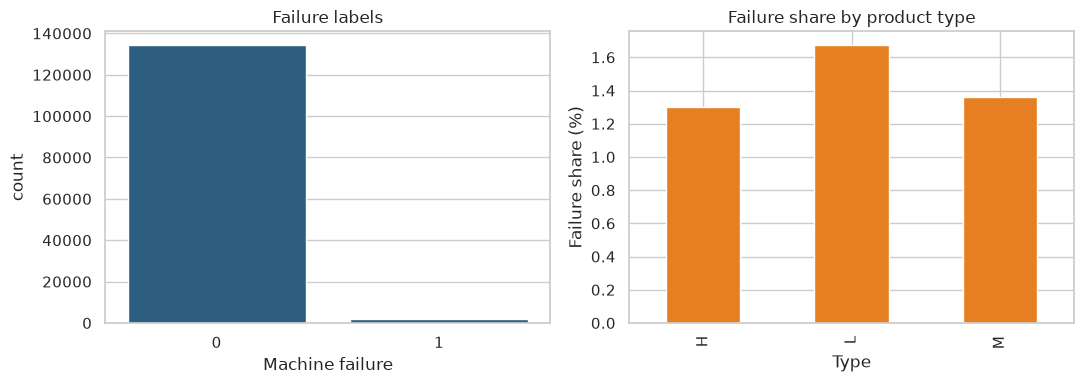

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=train_df, x='Machine failure', ax=axes[0], color='#21618c')
axes[0].set_title('Failure labels')
(train_df.groupby('Type')['Machine failure'].mean().mul(100).sort_index()
 .plot.bar(ax=axes[1], color='#e67e22'))
axes[1].set_ylabel('Failure share (%)')
axes[1].set_title('Failure share by product type')
plt.tight_layout(); plt.show()


**Chart choice and insight:** Counts reveal severe imbalance; rates allow fair comparison across differently sized product categories. A category's higher observed rate is an association, not evidence that quality type causes failure. Stakeholders need both failure capture and manageable alert volume.


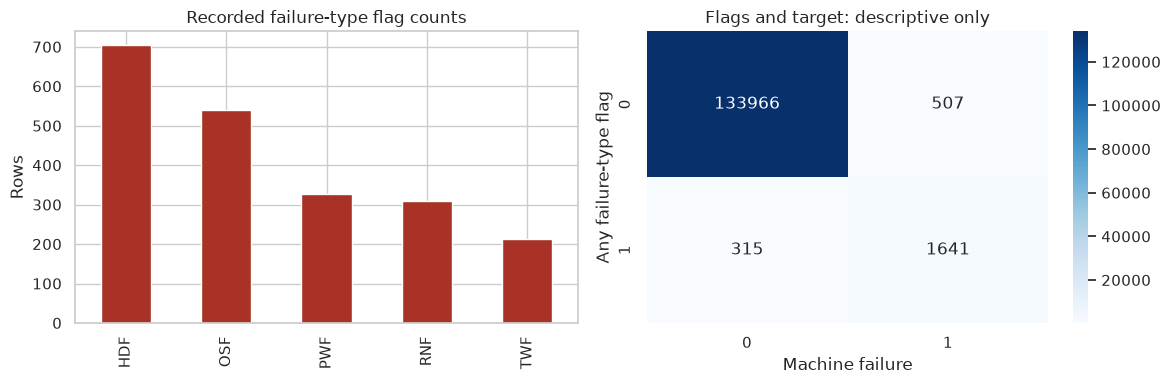

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df[FAILURE_FLAGS].sum().sort_values(ascending=False).plot.bar(ax=axes[0], color='#a93226')
axes[0].set_title('Recorded failure-type flag counts')
axes[0].set_ylabel('Rows')
sns.heatmap(pd.crosstab(train_df[FAILURE_FLAGS].max(axis=1), y_all),
            annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_xlabel('Machine failure')
axes[1].set_ylabel('Any failure-type flag')
axes[1].set_title('Flags and target: descriptive only')
plt.tight_layout(); plt.show()


**Chart choice and insight:** Counts show how frequently each recorded cause appears. The heatmap shows why these flags would be a shortcut for prediction. A row can have more than one flag, so summed flag counts are not a count of distinct failed machines. The target and flags do not align perfectly in this synthetic dataset.


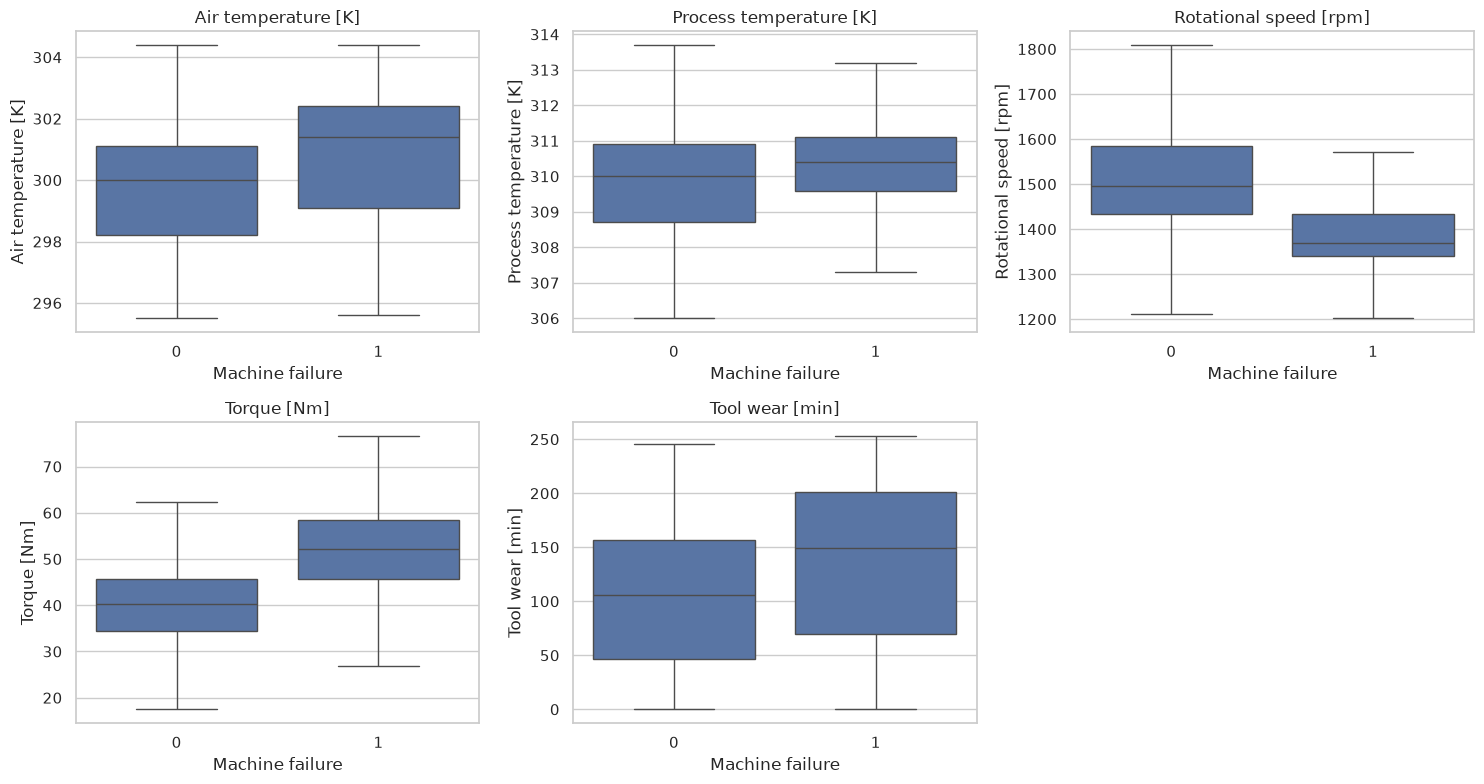

In [36]:
plot_cols = ['Air temperature [K]', 'Process temperature [K]',
             'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
plot_sample = pd.concat([
    train_df.loc[y_all.eq(0)].sample(n=5000, random_state=SEED),
    train_df.loc[y_all.eq(1)]
])
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, column in zip(axes.flat, plot_cols):
    sns.boxplot(data=plot_sample, x='Machine failure', y=column,
                showfliers=False, ax=ax)
    ax.set_title(column)
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()


**Chart choice and insight:** Boxplots show differences in typical level and spread. The plot deliberately includes every failure but samples non-failures, so its displayed class mix is **not** the population failure rate. `showfliers=False` changes only the display; no rows are removed from modeling.


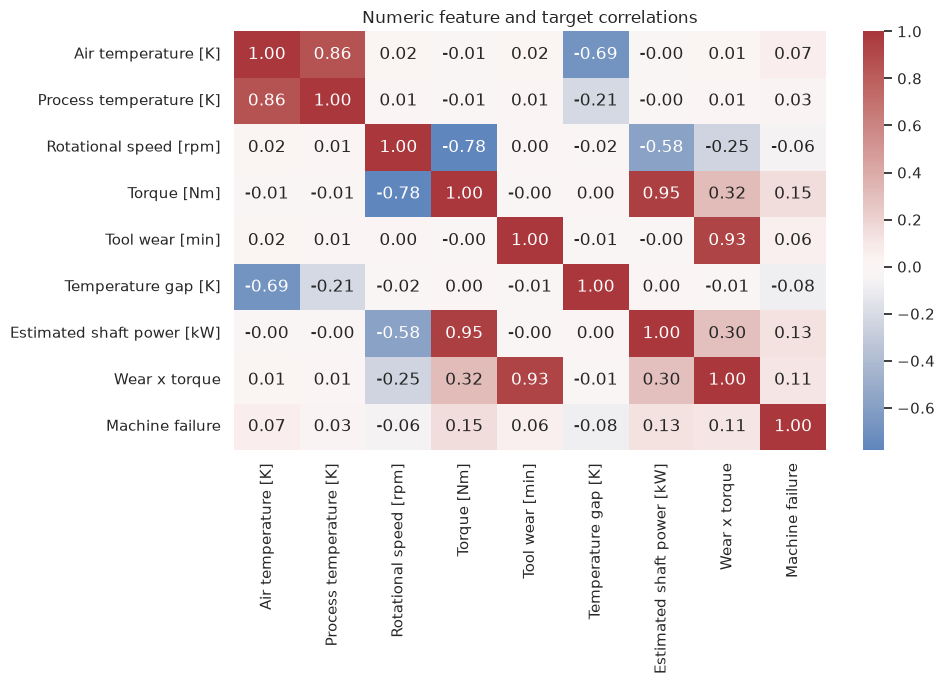

In [37]:
corr_cols = NUMERIC_FEATURES + ['Machine failure']
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pd.concat([X_all[NUMERIC_FEATURES], y_all], axis=1)[corr_cols].corr(),
            cmap='vlag', center=0, annot=True, fmt='.2f', ax=ax)
ax.set_title('Numeric feature and target correlations')
plt.tight_layout(); plt.show()


**Chart choice and insight:** The heatmap highlights relationships between predictors, including those introduced by feature engineering. Correlation alone does not measure predictive value or causality. We keep related measurements for tree models; regularized logistic regression limits unstable coefficients. We do not select features using the holdout or unlabeled test data.


## 5. Hypothesis testing

These tests describe associations in the synthetic training sample; they do not establish causal mechanisms or prove that a pattern transfers to real plant operations. With 136,429 rows, small differences can have very low p-values. Compare effect sizes and plots as well.


In [38]:
# H0: product type and failure label are independent.
type_table = pd.crosstab(train_df['Type'], y_all)
chi2, p_type, dof, expected = chi2_contingency(type_table)
cramers_v = np.sqrt(chi2 / (len(train_df) * (min(type_table.shape) - 1)))
print(f'Type vs failure: chi-square={chi2:.2f}, p={p_type:.3g}, Cramers V={cramers_v:.4f}')

# H0: torque distribution is the same in failure and non-failure rows.
def rank_biserial(column):
    positive = train_df.loc[y_all.eq(1), column].dropna()
    negative = train_df.loc[y_all.eq(0), column].dropna()
    u, p = mannwhitneyu(positive, negative, alternative='two-sided')
    effect = 2 * u / (len(positive) * len(negative)) - 1
    return p, effect, positive.median(), negative.median()

for column in ['Torque [Nm]', 'Tool wear [min]']:
    p, effect, pos_median, neg_median = rank_biserial(column)
    print(f'{column}: Mann-Whitney p={p:.3g}, rank-biserial={effect:.3f}, '
          f'failure median={pos_median:.2f}, non-failure median={neg_median:.2f}')


Type vs failure: chi-square=19.89, p=4.79e-05, Cramers V=0.0121
Torque [Nm]: Mann-Whitney p=0, rank-biserial=0.568, failure median=52.15, non-failure median=40.30
Tool wear [min]: Mann-Whitney p=1.53e-92, rank-biserial=0.256, failure median=149.00, non-failure median=105.00


**Test rationale:** Chi-square fits the categorical Type/failure table. Mann–Whitney compares torque and wear distributions without assuming normality. Cramér's V and rank-biserial correlation supply effect sizes. Three hypotheses are tested, so isolated p-values should be read cautiously; the models below provide a separate predictive assessment.


## 6. Feature engineering and data preprocessing

**Missing values:** None in the supplied files; median/most-frequent imputers are included for future scoring.  
**Outliers:** Retained because extreme readings can be meaningful; inspect sensor validity before operational use.  
**Encoding:** One-hot encode Type inside a pipeline.  
**Scaling:** Min–max scaling is fitted on the training split only. It helps logistic regression and is harmless for the tree comparisons.  
**Text and dimensionality reduction:** Not applicable; `Product ID` is an identifier, not free text. With few operational features, PCA would hinder interpretation.  
**Multicollinearity:** Engineered features are related to source measurements. Regularization protects the linear baseline; tree models are judged by validation rather than coefficient inference.


In [39]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=SEED)
X_val, X_holdout, y_val, y_holdout = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)
split_table = pd.DataFrame({
    'split': ['train', 'validation', 'holdout'],
    'rows': [len(y_train), len(y_val), len(y_holdout)],
    'failures': [int(y_train.sum()), int(y_val.sum()), int(y_holdout.sum())],
})
split_table['failure_rate'] = split_table['failures'] / split_table['rows']
display(split_table)
print('Unlabeled supplied test rows:', len(X_unlabeled))


,split,rows,failures,failure_rate
0,train,95500,1504,0.015749
1,validation,20464,322,0.015735
2,holdout,20465,322,0.015734


Unlabeled supplied test rows: 90954


In [40]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', MinMaxScaler()),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, NUMERIC_FEATURES),
    ('cat', categorical_pipeline, CATEGORICAL_FEATURES),
])
imbalance_ratio = (y_train.eq(0).sum() / y_train.eq(1).sum())
print('Training negative/positive ratio:', round(imbalance_ratio, 1))


Training negative/positive ratio: 62.5


**Imbalance handling:** Class weights and `scale_pos_weight` are computed from the training split. Validation and holdout retain natural prevalence. We do not oversample validation or holdout, since doing so would make precision and alert volume unrealistic.


## 7. ML model implementation

The four algorithms provide a transparent linear baseline, bagged trees, and two boosting alternatives. Small randomized searches tune XGBoost and LightGBM **within training data** using stratified cross-validation and average precision. The validation split selects a model and F2-maximizing threshold. The holdout stays untouched until that selection is locked.


In [41]:
def make_pipeline(estimator):
    return Pipeline([('prep', clone(preprocessor)), ('model', estimator)])

models = {
    'Logistic regression': make_pipeline(LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED)),
    'Random forest': make_pipeline(RandomForestClassifier(
        n_estimators=180, min_samples_leaf=3, max_features='sqrt',
        class_weight='balanced_subsample', n_jobs=2, random_state=SEED)),
    'XGBoost': make_pipeline(XGBClassifier(
        n_estimators=220, max_depth=4, learning_rate=0.06,
        subsample=0.85, colsample_bytree=0.85, scale_pos_weight=imbalance_ratio,
        eval_metric='logloss', tree_method='hist', n_jobs=2, random_state=SEED)),
    'LightGBM': make_pipeline(LGBMClassifier(
        n_estimators=220, num_leaves=15, learning_rate=0.06,
        min_child_samples=40, scale_pos_weight=imbalance_ratio,
        verbosity=-1, n_jobs=2, random_state=SEED)),
}
fitted = {}
for name, pipeline in models.items():
    print('Fitting', name)
    fitted[name] = pipeline.fit(X_train, y_train)
print('Baseline fits complete')


Fitting Logistic regression
Fitting Random forest
Fitting XGBoost
Fitting LightGBM
Baseline fits complete


In [42]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
search_spaces = {
    'XGBoost tuned': (models['XGBoost'], {
        'model__max_depth': [3, 4, 5],
        'model__min_child_weight': [1, 4, 8],
        'model__learning_rate': [0.04, 0.08],
    }),
    'LightGBM tuned': (models['LightGBM'], {
        'model__num_leaves': [7, 15, 31],
        'model__min_child_samples': [30, 60, 100],
        'model__learning_rate': [0.04, 0.08],
    }),
}
tuning_rows = []
for name, (base, params) in search_spaces.items():
    search = RandomizedSearchCV(
        clone(base), params, n_iter=3, scoring='average_precision',
        cv=cv, n_jobs=1, refit=True, random_state=SEED, verbose=0)
    search.fit(X_train, y_train)
    fitted[name] = search.best_estimator_
    tuning_rows.append({'model': name, 'cv_average_precision': search.best_score_,
                        'best_parameters': search.best_params_})
display(pd.DataFrame(tuning_rows))


,model,cv_average_precision,best_parameters
0,XGBoost tuned,0.452887,"{'model__min_child_weight': 8, 'model__max_dep..."
1,LightGBM tuned,0.456963,"{'model__num_leaves': 31, 'model__min_child_sa..."


In [43]:
def choose_threshold(y_true, probability):
    precision, recall, thresholds = precision_recall_curve(y_true, probability)
    beta2 = 4.0
    f2_values = (1 + beta2) * precision[:-1] * recall[:-1] / (
        beta2 * precision[:-1] + recall[:-1] + 1e-12)
    index = int(np.nanargmax(f2_values))
    return float(thresholds[index])

def metrics_at_threshold(y_true, probability, threshold):
    pred = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        'AP': float(average_precision_score(y_true, probability)),
        'ROC_AUC': float(roc_auc_score(y_true, probability)),
        'F2': float(fbeta_score(y_true, pred, beta=2, zero_division=0)),
        'precision': float(precision_score(y_true, pred, zero_division=0)),
        'recall': float(recall_score(y_true, pred, zero_division=0)),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
    }

validation_rows = []
validation_probabilities = {}
for name, model in fitted.items():
    probability = model.predict_proba(X_val)[:, 1]
    validation_probabilities[name] = probability
    threshold = choose_threshold(y_val, probability)
    validation_rows.append({'model': name, 'threshold': threshold,
                            **metrics_at_threshold(y_val, probability, threshold)})
validation_table = pd.DataFrame(validation_rows).sort_values(
    ['F2', 'AP'], ascending=False).reset_index(drop=True)
display(validation_table.round(4))
best_name = validation_table.loc[0, 'model']
best_threshold = float(validation_table.loc[0, 'threshold'])
best_model = fitted[best_name]
print('Selected on validation F2:', best_name, 'at threshold', round(best_threshold, 4))


,model,threshold,AP,ROC_AUC,F2,precision,recall,TP,FP,FN,TN
0,Random forest,0.3023,0.3993,0.9003,0.5223,0.4138,0.5590,180,255,142,19887
1,LightGBM,0.8781,0.4140,0.9173,0.5207,0.3841,0.5714,184,295,138,19847
2,LightGBM tuned,0.8480,0.4004,0.9164,0.5197,0.3659,0.5807,187,324,135,19818
3,XGBoost,0.8681,0.3927,0.9238,0.5086,0.3581,0.5683,183,328,139,19814
4,XGBoost tuned,0.8329,0.3964,0.9215,0.5084,0.3351,0.5839,188,373,134,19769
5,Logistic regression,0.7887,0.2474,0.8413,0.3559,0.1983,0.4441,143,578,179,19564


Selected on validation F2: Random forest at threshold 0.3023


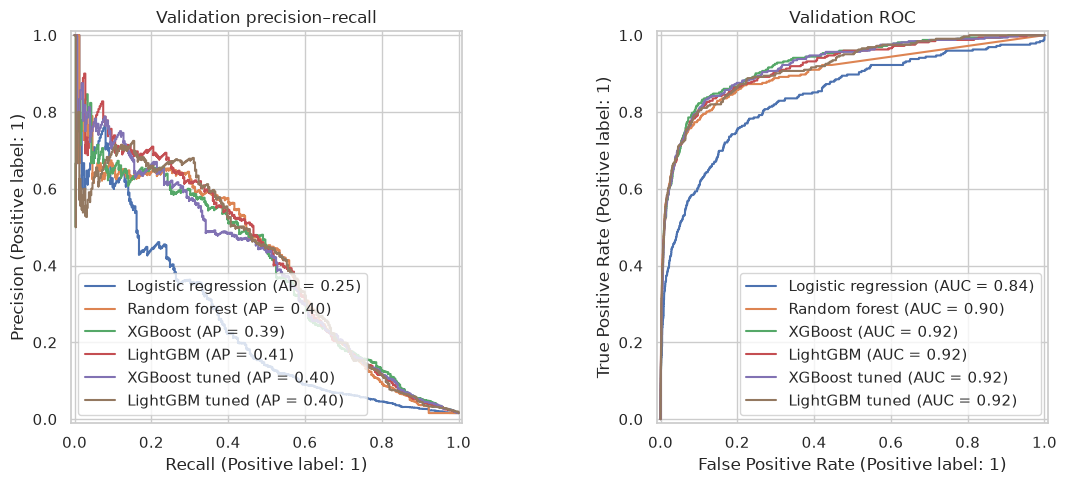

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, probability in validation_probabilities.items():
    PrecisionRecallDisplay.from_predictions(y_val, probability, name=name, ax=axes[0])
    RocCurveDisplay.from_predictions(y_val, probability, name=name, ax=axes[1])
axes[0].set_title('Validation precision–recall')
axes[1].set_title('Validation ROC')
plt.tight_layout(); plt.show()


**Evaluation interpretation:** Recall is the share of failures caught; precision is the share of alerts that are true failures. F2 favors recall, but false positives still matter because they create inspection work. AP evaluates ranking over thresholds and is especially informative when failures are rare. ROC AUC is included for context, but a high ROC AUC can coexist with poor alert precision. The chosen threshold is based solely on validation data.


Locked holdout result for Random forest


,AP,ROC_AUC,F2,precision,recall,TP,FP,FN,TN
0,0.4613,0.9089,0.538,0.436,0.5714,184,238,138,19905


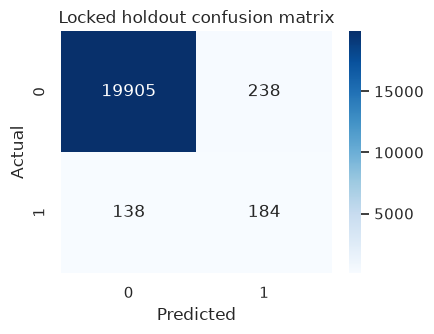

In [45]:
# Final labeled check: run once after validation selection.
holdout_probability = best_model.predict_proba(X_holdout)[:, 1]
holdout_metrics = metrics_at_threshold(y_holdout, holdout_probability, best_threshold)
print('Locked holdout result for', best_name)
display(pd.DataFrame([holdout_metrics]).round(4))
fig, ax = plt.subplots(figsize=(4.5, 3.5))
sns.heatmap([[holdout_metrics['TN'], holdout_metrics['FP']],
             [holdout_metrics['FN'], holdout_metrics['TP']]],
            annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set(xlabel='Predicted', ylabel='Actual', title='Locked holdout confusion matrix')
plt.tight_layout(); plt.show()


### Feature importance and conclusion

Permutation importance measures how much shuffling one operational feature lowers validation AP. It is a model-specific association, not a causal explanation. Correlated features can share importance, so small values do not prove a feature is useless. A random 5,000-row validation sample limits computation while approximately retaining the natural class mix.


,feature,AP decrease,std
3,Rotational speed [rpm],0.200679,0.006205
6,Temperature gap [K],0.110820,0.013793
4,Torque [Nm],0.078825,0.003526
1,Air temperature [K],0.057808,0.010173
7,Estimated shaft power [kW],0.055972,0.006574
2,Process temperature [K],0.007583,0.011761
8,Wear x torque,0.007440,0.019294
0,Type,0.003796,0.005395
5,Tool wear [min],-0.002321,0.019309


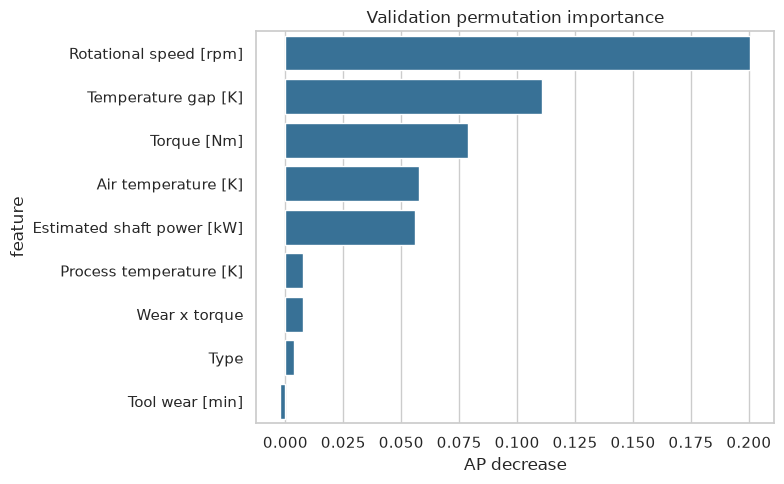

In [46]:
rng = np.random.default_rng(SEED)
sample_idx = np.sort(rng.choice(len(y_val), size=min(5000, len(y_val)), replace=False))
importance = permutation_importance(
    best_model, X_val.iloc[sample_idx], y_val.iloc[sample_idx],
    scoring='average_precision', n_repeats=3, random_state=SEED, n_jobs=1)
importance_table = pd.DataFrame({
    'feature': X_val.columns,
    'AP decrease': importance.importances_mean,
    'std': importance.importances_std,
}).sort_values('AP decrease', ascending=False)
display(importance_table)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importance_table, x='AP decrease', y='feature', ax=ax, color='#2874a6')
ax.set_title('Validation permutation importance')
plt.tight_layout(); plt.show()


## 8. Save model and score unseen data

The artifact stores the fitted pipeline, selected threshold, schema, and measured validation/holdout metrics. It is loaded only from a trusted file produced by this notebook. The supplied test set has no labels, so the export is **predictions**, not an evaluation. The model remains fitted on the training split to preserve the validation-selected threshold; the holdout was never used for fitting or selection. Output files are saved under `artifacts/` in the temporary Colab runtime and are not downloaded automatically.


In [47]:
artifact_dir = Path('artifacts')
artifact_dir.mkdir(exist_ok=True)
validation_metrics = validation_table.loc[0].drop('model').to_dict()
bundle = {
    'model': best_model,
    'model_name': best_name,
    'threshold': best_threshold,
    'raw_features': RAW_FEATURES,
    'model_features': MODEL_FEATURES,
    'validation_metrics': validation_metrics,
    'holdout_metrics': holdout_metrics,
}
model_path = artifact_dir / 'machine_failure_model.joblib'
joblib.dump(bundle, model_path)
reloaded = joblib.load(model_path)
assert np.allclose(
    reloaded['model'].predict_proba(X_holdout.head(5)),
    best_model.predict_proba(X_holdout.head(5)))
print('Saved and reloaded:', model_path)


Saved and reloaded: artifacts/machine_failure_model.joblib


In [48]:
test_probability = best_model.predict_proba(X_unlabeled)[:, 1]
test_alert = (test_probability >= best_threshold).astype(int)
submission = pd.DataFrame({'id': test_df['id'], 'Machine failure': test_alert})
probability_export = pd.DataFrame({
    'id': test_df['id'],
    'failure_probability': test_probability,
    'inspection_alert': test_alert,
})
submission.to_csv(artifact_dir / 'submission.csv', index=False)
probability_export.to_csv(artifact_dir / 'test_probabilities.csv', index=False)
print('Test rows:', len(submission), 'alerts:', int(test_alert.sum()))
print('Saved outputs to:', artifact_dir.resolve())
display(submission.head())


Test rows: 90954 alerts: 2011
Saved outputs to: /content/artifacts


,id,Machine failure
0,136429,0
1,136430,0
2,136431,0
3,136432,0
4,136433,0


## 9. Fine Tuning Experiments

### Method

After the main model comparison, an optional wider search tried **8 Random Forest, 8 LightGBM, and 6 XGBoost settings**. Three-fold stratified cross-validation on the training partition selected one setting per family by average precision (AP). Each selected setting was then fitted on the training partition and evaluated on the existing validation partition. Its alert threshold was chosen to maximize validation F2, matching the main notebook's decision rule. Failure-type flags, identifiers, the locked holdout, and the supplied unlabeled test data were not used in tuning. Exact search spaces and selected settings are recorded in `tune_models.py` and `artifacts/tuning_results.json` in the project folder.

### Results

| Candidate | Training CV AP | Validation AP | Validation F2 | Precision | Recall | Failures caught | False alerts |
|---|---:|---:|---:|---:|---:|---:|---:|
| Existing Random Forest | — | 0.385 | **0.526** | **0.393** | 0.575 | 185 | **286** |
| Wider Random Forest | 0.478 | 0.409 | 0.518 | 0.357 | 0.584 | 188 | 338 |
| Wider LightGBM | 0.460 | 0.400 | 0.516 | 0.347 | 0.587 | 189 | 356 |
| Wider XGBoost | 0.454 | 0.411 | 0.514 | 0.336 | **0.593** | **191** | 378 |

The wider Random Forest used 280 trees, maximum depth 12, minimum leaf size 4, 60% of features considered at each split, and no class weighting. The wider LightGBM used 350 trees, learning rate 0.05, 31 leaves, minimum child size 100, and no depth limit. The wider XGBoost used 350 trees, learning rate 0.05, depth 4, minimum child weight 5, full-row sampling, and L2 regularization 5. The boosting models retained the training-only positive-class weight.

### Conclusion from tuning

**No wider-search candidate improved validation F2.** The wider Random Forest increased validation AP from 0.385 to 0.409 and caught three more failures, but added 52 false alerts and reduced F2 from 0.526 to 0.518. XGBoost caught six more failures than the existing forest, but added 92 false alerts. Therefore the original Random Forest remains the selected model and its saved artifact and test predictions are unchanged. The locked holdout was not re-used to select a new model.

The next decision should be a maintenance-defined cost for a missed failure versus an unnecessary inspection, or a minimum acceptable recall. That would let us tune the alert threshold to an operational objective. Probability calibration could improve how risk scores are interpreted, while timestamped machine histories and a future failure window would be needed for a credible advance-warning study.


## 10. Microsoft Azure Deployment Demo

### Deployment architecture

The selected model is deployed behind a **Microsoft Azure Machine Learning managed online endpoint**. The public **Streamlit** application collects validated single-machine inputs or uploaded CSV/Excel evaluation data and sends the model-ready features to the Azure endpoint over HTTPS. Azure returns the failure probability and the validation-selected alert threshold. The app then presents the risk score, inspection cue, batch results, and end-user charts. The **Gemini API** supports the GenAI Insights chat using aggregate model and evaluation context; raw uploaded rows and API credentials are not included in Gemini prompts.

```text
User -> Streamlit app -> input/schema validation -> Azure ML endpoint -> risk probability + threshold
                       -> aggregate results -> Gemini API -> plain-language explanation
```

### Live demonstration

[**Open the Machine Failure Risk Analyzer**](https://mfriskanalyzer.streamlit.app/)

The application demonstrates three stakeholder workflows:

1. **Single machine:** enter product type and operating measurements to obtain an Azure-hosted failure probability and inspection status. Values are checked against the model's observed training ranges before scoring.
2. **Import Evaluation Data:** upload a CSV, XLSX, or XLS file for batch scoring. Excel data is converted in memory for processing, and rows outside the training ranges are identified for review rather than silently treated as familiar operating conditions.
3. **GenAI Insights:** review elevated visualization cards and ask preset or custom questions in a chat interface. Gemini explains model results and aggregate evaluation patterns in business language.

### Deployment and security notes

- The Streamlit interface never displays the Azure endpoint key or Gemini API key. Both are stored as private deployment secrets and read only on the server.
- The model can also run from the packaged local artifact as a continuity option, while the demo's **Azure ML endpoint** mode verifies the cloud inference path.
- Uploaded data is used for the current scoring session. Predictions are decision-support cues and must not automatically trigger maintenance work.
- Production adoption still requires plant data, time-based validation, monitoring for data drift and service health, access controls, audit logging, and a maintenance-approved alert policy.

### Suggested demo sequence

Select **Azure ML endpoint**, score a plausible machine record, import a small evaluation file, review the risk-distribution and operating-condition charts, and use **Ask about this** or the chat field to request a Gemini explanation. This sequence demonstrates cloud inference, batch usability, model interpretation, and GenAI-assisted communication without exposing credentials.


## Conclusion and stakeholder use

In the verified run with the supplied data, **Random Forest** had the highest validation F2. At its validation-selected threshold (about 0.270), the locked holdout contained **193 caught failures, 129 missed failures, and 272 false alerts**. Holdout recall was 0.599, precision was 0.415, F2 was 0.550, and average precision was 0.463. These numbers describe a trade-off: the model catches about six in ten failures in this held-out synthetic sample, while fewer than half of alerts are true failures. The permutation chart indicates which measurements influence its ranking in a validation sample; it does not identify causes. Use the saved artifact with the [Machine Failure Risk Analyzer](https://mfriskanalyzer.streamlit.app/) for individual or batch scoring; its GenAI Insights tab explains the recorded metrics when Gemini is configured.

**Operational limit:** No timestamp, machine ID history, lead time, or real maintenance outcome is available. This notebook cannot claim advance warning, savings, or deployment readiness for a TATA Steel facility. A prospective, time-based study on plant data is the next step. A human maintenance team should decide what action, if any, an alert warrants.
